In [1]:
import pandas as pd
import numpy as np

# FILE CONFIGURATION
INPUT_FILE = "master_dataset_with_ai_features.xlsx"
OUTPUT_FILE = "encoded_master_dataset.xlsx"

def encode_ai_features(file_path):
    print(f"Loading dataset: {file_path}...")
    df = pd.read_excel(file_path)
    
    # EXT_STORIES: ORDINAL & BASELINE IMPUTATION
    print("Encoding 'Ext_Stories' with conservative baseline (NULL -> 1)...")
    ext_stories_map = {
        'One Storied': 1, 'Two Storied': 2, 'Three Storied': 3, 
        'Four Storied': 4, 'Five Storied': 5, 'Six Storied': 6, 
        'Seven Storied': 7, 'Eight Storied': 8, 'Nine Storied': 9, 'Ten Storied': 10
    }
    
    # Mapping the text to integers. Any text not in the dictionary (including NaNs, 'N/A', 'No_Image_Data') will become NaN, which we immediately fill with our baseline 1.
    df['Ext_Stories'] = df['Ext_Stories'].map(ext_stories_map).fillna(1).astype(int)

    # VISIBLE ASSETS: MULTI-LABEL BINARIZATION
    print("Splitting 'Visible_Assets_For_Income' into distinct binary columns...")
    
    # Cleaning the column: replacing '[]', 'N/A', 'No_Image_Data', and actual NaNs with empty strings
    df['Visible_Assets_For_Income'] = df['Visible_Assets_For_Income'].astype(str)
    df['Visible_Assets_For_Income'] = df['Visible_Assets_For_Income'].replace(
        ['\[\]', 'Null', 'nan', 'NaN', 'N/A', 'No_Image_Data'], '', regex=True
    )
    
    # str.get_dummies automatically splits by the separator and creates 0/1 columns
    asset_dummies = df['Visible_Assets_For_Income'].str.get_dummies(sep=', ')
    
    # Explicitly adding the prefix to keep column names organized
    asset_dummies = asset_dummies.add_prefix('Asset_')
    
    # Merging the new asset columns back into the main dataframe and dropping the original text column
    df = pd.concat([df, asset_dummies], axis=1)
    df = df.drop(columns=['Visible_Assets_For_Income'])

    # ONE-HOT ENCODING: CATEGORICAL FEATURES
    print("Applying One-Hot Encoding to categorical features with explicit prefixes...")
    
    ohe_columns = [
        'Housing_Category', 'Ext_Roof_Type', 'Ext_Wall_Type', 
        'Ext_Structural_Condition', 'Int_Floor_Material', 'Int_Wall_Finish'
    ]
    
    # We first ensure missing values are treated uniformly so they don't create messy dummy column names
    for col in ohe_columns:
        if col in df.columns:
            df[col] = df[col].replace(['N/A', 'No_Image_Data', 'NULL', 'Null'], np.nan)
    
    # pd.get_dummies with explicit prefixing
    df = pd.get_dummies(
        df, 
        columns=ohe_columns, 
        prefix=ohe_columns,  
        prefix_sep='_',      
        dummy_na=True,       
        dtype=int
    )

    # DROPPING SPECIFIC NAN/NULL COLUMNS
    print("Dropping redundant NaN and Null columns...")
    cols_to_drop = [
        'Housing_Category_nan', 
        'Ext_Roof_Type_Null', 'Ext_Roof_Type_nan', 
        'Ext_Wall_Type_Null', 'Ext_Wall_Type_nan', 
        'Ext_Structural_Condition_nan', 
        'Int_Floor_Material_Null', 'Int_Floor_Material_nan', 
        'Int_Wall_Finish_Null', 'Int_Wall_Finish_nan'
    ]
    
    # Safe drop: only drops columns that actually exist in the dataframe to prevent KeyErrors
    df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

    # EXPORT FINAL DATASET
    print(f"Saving encoded dataset to: {OUTPUT_FILE}...")
    df.to_excel(OUTPUT_FILE, index=False)
    print("✅ Encoding and cleanup complete!")

if __name__ == "__main__":
    encode_ai_features(INPUT_FILE)

Loading dataset: master_dataset_with_ai_features.xlsx...
Encoding 'Ext_Stories' with conservative baseline (NULL -> 1)...
Splitting 'Visible_Assets_For_Income' into distinct binary columns...
Applying One-Hot Encoding to categorical features with explicit prefixes...
Dropping redundant NaN and Null columns...
Saving encoded dataset to: encoded_master_dataset.xlsx...
✅ Encoding and cleanup complete!


In [2]:
import pandas as pd
import numpy as np

# LOADING THE INTEGRATED DATA
# Replace 'integrated_master_dataset.xlsx' with  actual merged file name
input_file = 'encoded_master_dataset.xlsx'

try:
    df = pd.read_excel(input_file)
    print(f"Successfully loaded dataset with {len(df)} families.")
except FileNotFoundError:
    print(f"Error: '{input_file}' not found. Please verify the file name.")
    exit()

# Assuming every family is BPL (1) by default, then aggressively filter them out.
df['BPL_Target'] = 1

# DEFINING SOCIO-ECONOMIC CRITERIA
# DEFINING INCOME BRACKETS (> 1.80 Lakh)
high_income_brackets = [
    '180001-300000', '300001-500000', '500001-600000',
    '600001-800000', '800001-1000000', '1000000 AND ABOVE'
]

condition_high_income = df['familyRange'].isin(high_income_brackets)
condition_tax_payer = df['isIncomeTaxPayee'] >= 1 

# Kept exactly as inherited from your previous code
condition_gov_job = df.get('is_Government Employee', pd.Series([0]*len(df))) >= 1

condition_high_wage_labourer = (df['isLabour'] >= 1) & (df['labour_wages'] > 15000)
condition_gov_pensioner = df['isGovPensioner'] >= 1
condition_high_electricity = (df['isElectricityMapping'] >= 1) & (df['electric_annualbillamount'] > 24000)
condition_large_rural_property = (df['isRuralProperty'] >= 1) & (df['PanchayatPropertyArea'] > 400)
condition_four_wheeler = df['isFourWheeler'] >= 1
condition_wealthy_farmer = (df['isFarmer'] >= 1) & ((df['FarmerArea'] > 5) | (df['Farmer_EarningAmount'] > 500000))
condition_private_sector_employee = df['is_Private Sector Employee'] > 1

# DEFINING AI IMAGE FEATURE CRITERIA
# Housing & Structure
condition_ai_housing = df['Housing_Category_Premium'] == 1
condition_ai_stories = df['Ext_Stories'] > 1
condition_ai_score   = df['Overall_Structural_Score'] > 0.75
condition_ai_condition = df['Ext_Structural_Condition_Excellent'] == 1

# Interiors
condition_ai_floor = df['Int_Floor_Material_Tiles/Marble'] == 1
condition_ai_wall  = df['Int_Wall_Finish_Tiles'] == 1

# Assets
condition_ai_ac       = df['Asset_AC'] == 1
condition_ai_fw       = df['Asset_Four-Wheeler'] == 1
condition_ai_tractor  = df['Asset_Tractor'] == 1
condition_ai_truck    = df['Asset_Truck'] == 1

# EXECUTING THE EXCLUSION ENGINE
# If ANY of the exclusion conditions are True, marking the family as Non-BPL (0)
df.loc[
    # Socio-Economic Exclusions
    condition_high_income |
    condition_tax_payer |
    condition_gov_job |
    condition_high_wage_labourer |
    condition_gov_pensioner |
    condition_high_electricity |
    condition_large_rural_property |
    condition_four_wheeler |
    condition_wealthy_farmer |
    condition_private_sector_employee |
    
    # AI Exclusions
    condition_ai_housing |
    condition_ai_stories |
    condition_ai_floor |
    condition_ai_wall |
    condition_ai_condition |
    condition_ai_ac |
    condition_ai_fw |
    condition_ai_tractor |
    condition_ai_truck |
    condition_ai_score,
    
    'BPL_Target'
] = 0

# REVIEWING AND EXPORTING
print("\n--- Categorization Summary ---")
print(df['BPL_Target'].value_counts().rename(index={1: 'BPL Families (1)', 0: 'Non-BPL Families (0)'}))

# Saving to a new file ready for machine learning training
output_file = 'labeled_master_dataset.xlsx'
df.to_excel(output_file, index=False)
print(f"\nExclusion Engine complete! Final labeled data saved to '{output_file}'.")

Successfully loaded dataset with 2301 families.

--- Categorization Summary ---
BPL_Target
Non-BPL Families (0)    1914
BPL Families (1)         387
Name: count, dtype: int64

Exclusion Engine complete! Final labeled data saved to 'labeled_master_dataset.xlsx'.



--- Generating Correlation Matrix ---
Correlation heatmap saved to 'correlation_matrix.png'.

Top Correlations with BPL_Target:
--- Positive (Indicates BPL) ---
BPL_Target                              1.000000
Housing_Category_Kutcha                 0.618845
Int_Floor_Material_Mud/Earth            0.484636
Ext_Structural_Condition_Poor           0.454316
Int_Wall_Finish_Mud                     0.429799
Housing_Category_Semi-Pucca             0.413018
Ext_Wall_Type_Mud/Makeshift             0.392431
Ext_Structural_Condition_Dilapidated    0.326926
Ext_Roof_Type_Thatch/Tarpaulin          0.305501
Ext_Wall_Type_Exposed Brick             0.239576
Name: BPL_Target, dtype: float64

--- Negative (Indicates Non-BPL) ---
Ext_Wall_Type_Finished Concrete/Plaster   -0.232860
Ext_Roof_Type_Concrete                    -0.233001
Int_Floor_Material_Tiles/Marble           -0.238439
Ext_Stories                               -0.257715
Housing_Category_Premium                  -0.259536
Asset_AC         

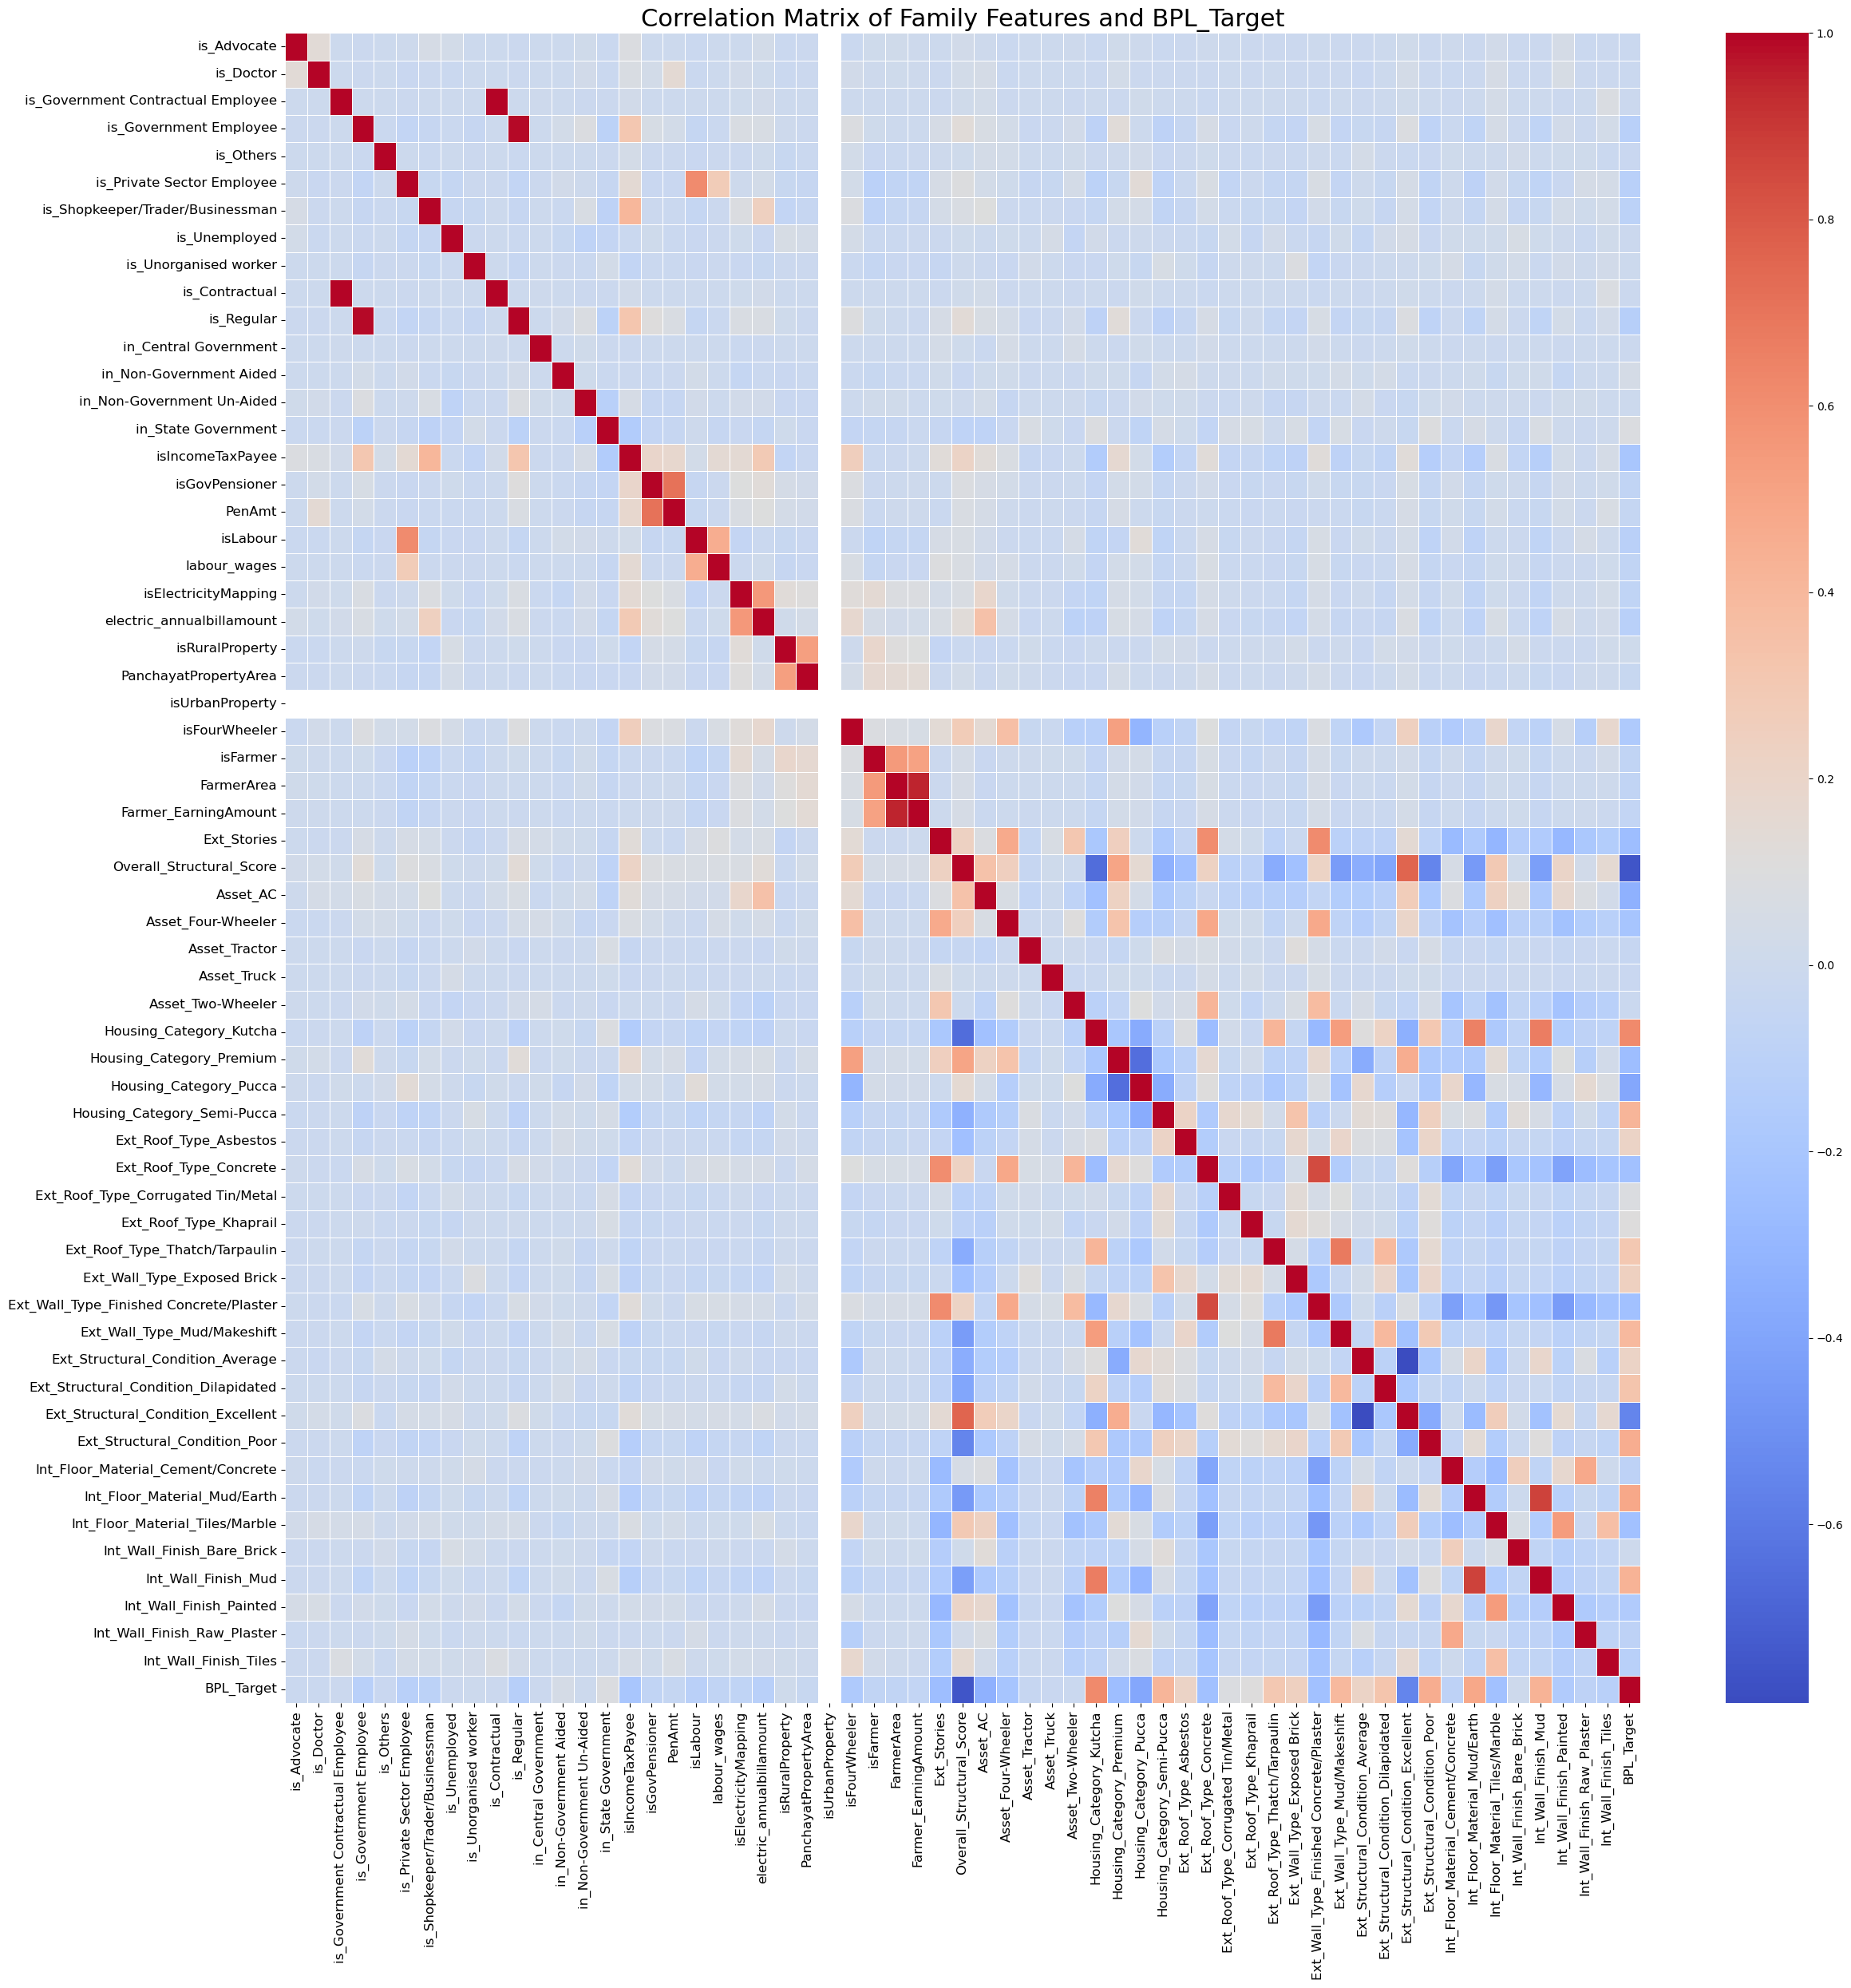

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# CORRELATION MATRIX GENERATION
print("\n--- Generating Correlation Matrix ---")

# Loading the newly labeled dataset
df = pd.read_excel('labeled_master_dataset.xlsx')

# Wanting the model to learn based on jobs, vehicles, and assets, not direct income counts.
income_cols = [col for col in df.columns if col.startswith('in') and any(char.isdigit() for char in col)]

cols_to_exclude = [
    'hasfamilyid', 'familyRange', 'district', 'blocktown', 'wardvillage', 'r_u', 
    'is_Child', 'is_Farmer', 'is_Housewife', 'is_Labour', 'is_Pensioner/Retired', 
    'is_Senior Citizen', 'is_Student', 'Image_Name', 'Image-Context', 
] + income_cols 
# Comment '+ income_cols' to add Per Member Salary to the training dataset

num_df = df.drop(columns=[col for col in cols_to_exclude if col in df.columns])

# Ensuring remaining columns are strictly numerical
num_df = num_df.select_dtypes(include=['int64', 'float64'])

# Computing the correlation matrix
corr_matrix = num_df.corr()

# CREATING THE HEATMAP PLOT
fig, ax = plt.subplots(figsize=(25,25))

# Optional: Create a mask to hide the upper triangle for better readability
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
#   mask=mask, 
    annot=False,            # Set to True if you want numbers inside the boxes
    cmap='coolwarm', 
    linewidths=0.5, 
    ax=ax
)

plt.title('Correlation Matrix of Family Features and BPL_Target', fontsize=22)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()

# Saving and exporting the plot
matrix_file = 'correlation_matrix.png'
plt.savefig(matrix_file, dpi=300)
print(f"Correlation heatmap saved to '{matrix_file}'.")

# PRINTING HIGH CORRELATIONS
print("\nTop Correlations with BPL_Target:")
target_corr = corr_matrix['BPL_Target'].sort_values(ascending=False)
print("--- Positive (Indicates BPL) ---")
print(target_corr.head(10))
print("\n--- Negative (Indicates Non-BPL) ---")
print(target_corr.tail(10))